In [1]:
from typing import Annotated, TypedDict, List, Dict, Any, Optional
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from IPython.display import Image, display
import gradio as gr
import uuid
from dotenv import load_dotenv
import os
from math_tools import add, sub, mul, div

/home/elijah/elijah/ai-bc/projects/my_projects_agentic/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv(override=True)

True

In [3]:
class State(TypedDict):
    messages: Annotated[List[Any], add_messages]

In [ ]:
tools = [add, sub, mul, div]


worker_llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    #model="anthropic/claude-sonnet-4.6",
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=os.getenv("OPENROUTER_API_KEY")
)


worker_llm_with_tools = worker_llm.bind_tools(tools)

In [5]:
def worker(state: State) -> Dict[str, Any]:
    system_message = f"""You are a mathematician. You solve math questions in a clever way"""
    
    
    # Add in the system message

    found_system_message = False
    messages = state["messages"]
    for message in messages:
        if isinstance(message, SystemMessage):
            message.content = system_message
            found_system_message = True
    
    if not found_system_message:
        messages = [SystemMessage(content=system_message)] + messages
    
    # Invoke the LLM with tools
    response = worker_llm_with_tools.invoke(messages)
    
    # Return updated state
    return {
        "messages": [response],
    }

In [6]:
def worker_router(state: State) -> str:
    last_message = state["messages"][-1]
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"

In [7]:
# Set up Graph Builder with State
graph_builder = StateGraph(State)

# Add nodes
graph_builder.add_node("worker", worker)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Add edges
graph_builder.add_conditional_edges("worker", tools_condition, "tools")
graph_builder.add_edge("tools", "worker")
graph_builder.add_edge(START, "worker")

# Compile the graph
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

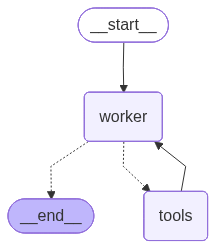

In [8]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
thread = 1


def process_message(message, history, thread):

    config = {"configurable": {"thread_id": thread}}

    state = {
        "messages": message
    }
    result = graph.invoke(state, config=config)

    return result["messages"][-1].content

In [13]:

with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as demo:
    gr.Markdown("## Sidekick Personal Co-worker")
    gr.ChatInterface(fn=process_message)
    
demo.launch()

/tmp/ipykernel_16007/4241374174.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as demo:


/home/elijah/elijah/ai-bc/projects/my_projects_agentic/.venv/lib/python3.12/site-packages/gradio/utils.py:1177: UserWarning: Expected 3 arguments for function <function process_message at 0x7faa1c1a60c0>, received 2.
  warnings.warn(
/home/elijah/elijah/ai-bc/projects/my_projects_agentic/.venv/lib/python3.12/site-packages/gradio/utils.py:1181: UserWarning: Expected at least 3 arguments for function <function process_message at 0x7faa1c1a60c0>, received 2.
  warnings.warn(
/home/elijah/elijah/ai-bc/projects/my_projects_agentic/.venv/lib/python3.12/site-packages/gradio/utils.py:1177: UserWarning: Expected 3 arguments for function <function process_message at 0x7faa0f7e28e0>, received 2.
  warnings.warn(
/home/elijah/elijah/ai-bc/projects/my_projects_agentic/.venv/lib/python3.12/site-packages/gradio/utils.py:1181: UserWarning: Expected at least 3 arguments for function <function process_message at 0x7faa0f7e28e0>, received 2.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


/home/elijah/elijah/ai-bc/projects/my_projects_agentic/.venv/lib/python3.12/site-packages/gradio/helpers.py:1083: UserWarning: Unexpected argument. Filling with None.
  warnings.warn("Unexpected argument. Filling with None.")
/home/elijah/elijah/ai-bc/projects/my_projects_agentic/.venv/lib/python3.12/site-packages/gradio/helpers.py:1083: UserWarning: Unexpected argument. Filling with None.
  warnings.warn("Unexpected argument. Filling with None.")
/home/elijah/elijah/ai-bc/projects/my_projects_agentic/.venv/lib/python3.12/site-packages/gradio/helpers.py:1083: UserWarning: Unexpected argument. Filling with None.
  warnings.warn("Unexpected argument. Filling with None.")
